In [1]:
"""
File: stock_data_plot.py
Title: Stock Data Download, Save, and Line Chart via Yahoo Finance
Author: Mahmoud A. Eissa
Description:
This script downloads historical stock data for a given ticker using yfinance,
prints the first five rows, saves the data to CSV, and plots a simple line chart of the Close price.
"""

'\nFile: stock_data_plot.py\nTitle: Stock Data Download, Save, and Line Chart via Yahoo Finance\nAuthor: Mahmoud A. Eissa\nDescription:\nThis script downloads historical stock data for a given ticker using yfinance,\nprints the first five rows, saves the data to CSV, and plots a simple line chart of the Close price.\n'

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
# -----------------------------
# Parameters
# -----------------------------
ticker = "PFE"       # Stock ticker symbol
period = "1y"        # Period to download (e.g., '1y', '6mo', '5d')
interval = "1d"      # Data interval ('1d', '1wk', '1mo')
start="2023-01-01"   # start date for data interval 
end="2024-01-01"      # end date for data interval
filename = f"{ticker}_data.csv"  # CSV file to save

In [4]:
# -----------------------------
# Download Data
# -----------------------------

# Download one year of historical data using start date & end date 

#data = yf.download(ticker,start=start,end=end, interval=interval)   

# Download one year of historical data using period from todaly to one year back

data = yf.download(ticker, period=period, interval=interval)

# Print first 5 rows
print(data.head())

C:\Users\hp\AppData\Local\Temp\ipykernel_13636\3128729517.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker            PFE        PFE        PFE        PFE       PFE
Date                                                            
2025-03-14  23.979412  24.016706  23.774301  23.886181  30298300
2025-03-17  24.287083  24.380316  23.858214  23.998062  32676900
2025-03-18  24.529488  24.613397  24.333700  24.436255  32958700
2025-03-19  24.436253  24.706628  24.315051  24.548132  42522700
2025-03-20  24.417606  24.520161  24.259111  24.473545  35378900


In [5]:
# -----------------------------
# Save to CSV
# -----------------------------
data.to_csv(filename)
print(f"Data saved to {filename}")

Data saved to PFE_data.csv


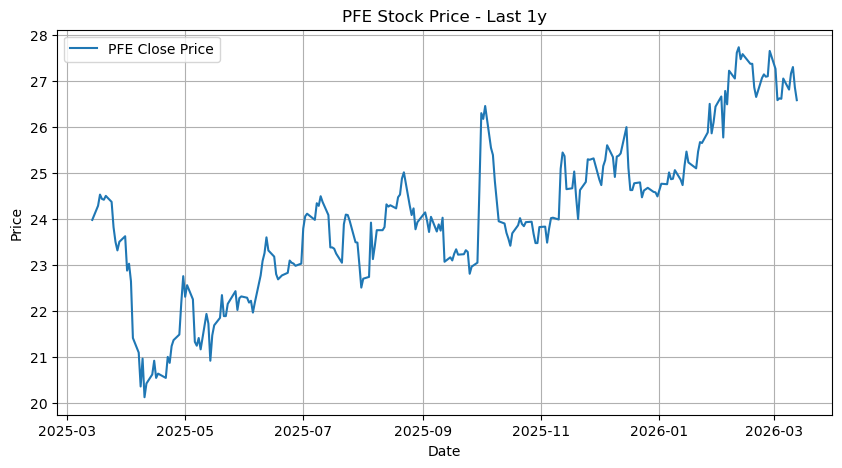

In [6]:
# -----------------------------
# Plot Close Price
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(data['Close'], label=f"{ticker} Close Price")
plt.title(f"{ticker} Stock Price - Last {period}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# -----------------------------
# Simple Return
# -----------------------------

# Use closing price
prices = data["Close"]

# Calculate simple return
simple_returns = prices.pct_change()

# Remove missing values
simple_returns = simple_returns.dropna()

print(simple_returns.head())

Ticker           PFE
Date                
2025-03-17  0.012831
2025-03-18  0.009981
2025-03-19 -0.003801
2025-03-20 -0.000763
2025-03-21  0.003437


In [8]:
# -----------------------------------
# Step 2: Calculate returns for 1D, 1W, 1M
# -----------------------------------

# Daily return
data["Return_1D"] = data["Close"].pct_change()

# Weekly return (5 trading days)
data["Return_1W"] = data["Close"].pct_change(5)

# Monthly return (21 trading days)
data["Return_1M"] = data["Close"].pct_change(21)

# Remove missing values
data = data.dropna()

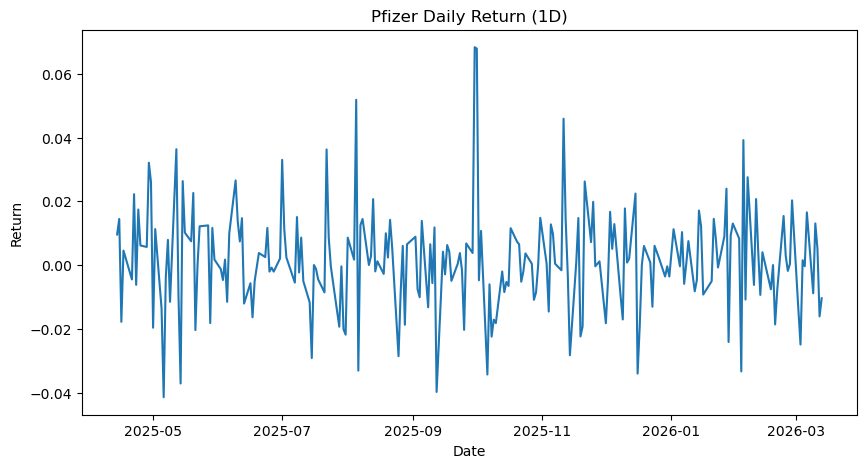

In [9]:
# -----------------------------------
# Step 3: Plot Daily Return
# -----------------------------------
plt.figure(figsize=(10,5))

plt.plot(data.index, data["Return_1D"])

plt.title("Pfizer Daily Return (1D)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

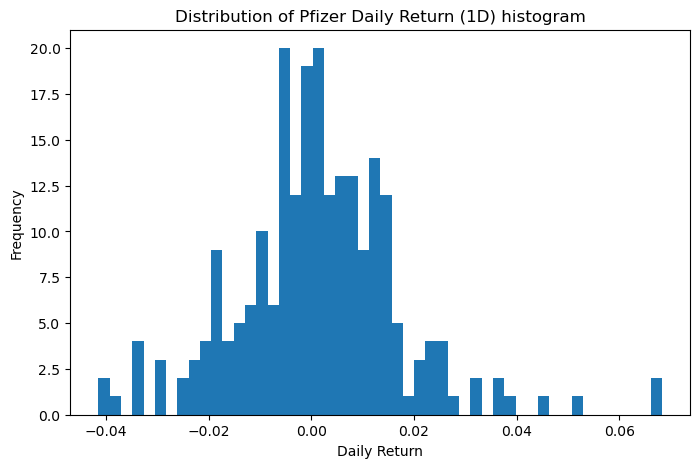

In [14]:
# -----------------------------------
# Step 3: Plot return distribution
# -----------------------------------
plt.figure(figsize=(8,5))

plt.hist(data["Return_1D"], bins=50)

plt.title("Distribution of Pfizer Daily Return (1D) histogram")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

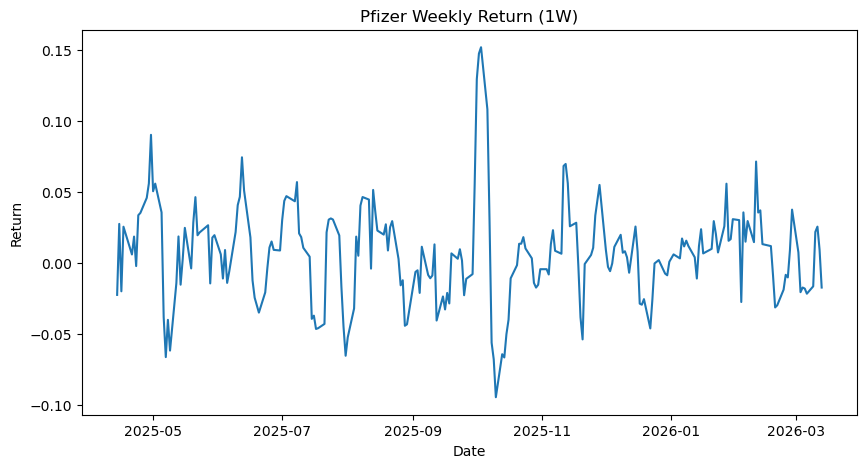

In [11]:
# -----------------------------------
# Step 4: Plot 1-Week Return
# -----------------------------------
plt.figure(figsize=(10,5))

plt.plot(data.index, data["Return_1W"])

plt.title("Pfizer Weekly Return (1W)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

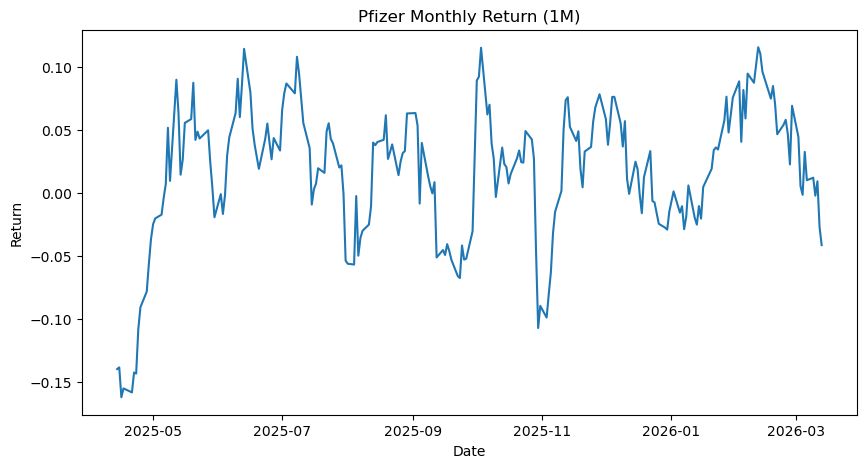

In [12]:
# -----------------------------------
# Step 5: Plot 1-Month Return
# -----------------------------------
plt.figure(figsize=(10,5))

plt.plot(data.index, data["Return_1M"])

plt.title("Pfizer Monthly Return (1M)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

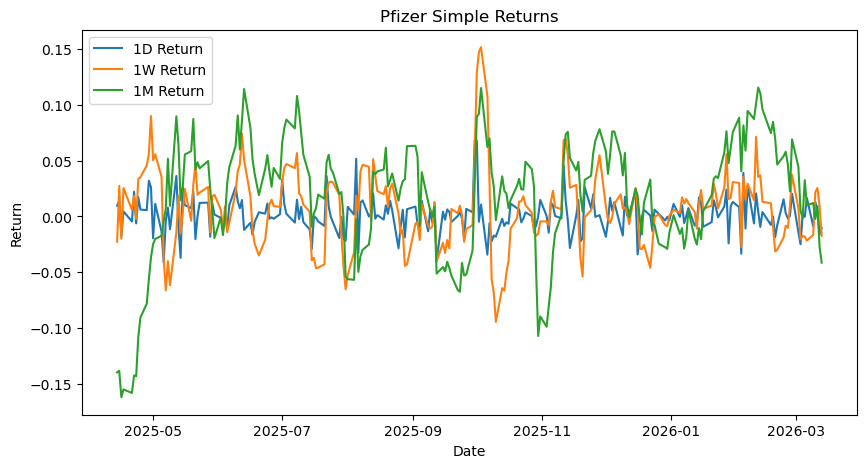

In [13]:
# -----------------------------------
# Step 4: Plot Multiple Returns
# -----------------------------------
plt.figure(figsize=(10,5))

plt.plot(data.index, data["Return_1D"], label="1D Return")
plt.plot(data.index, data["Return_1W"], label="1W Return")
plt.plot(data.index, data["Return_1M"], label="1M Return")

plt.title("Pfizer Simple Returns")
plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()

plt.show()